This notebook shows a model predicting medicare payment amount bease on volume, provider type, and risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

file_path = "../data/raw/Modified_Prov_Type_and_Round_Int_All_10_years.csv"

usecols = [
    "year",
    "Rndrng_Prvdr_Type",
    "Tot_Benes",
    "Tot_Srvcs",
    "Drug_Tot_Srvcs",
    "Bene_Avg_Risk_Scre",
    "Tot_Mdcr_Pymt_Amt"
]

df = pd.read_csv(file_path, usecols=usecols, low_memory=False)

# sanity check
print(df["year"].min(), df["year"].max())
print(df["year"].value_counts().sort_index().tail())


df.columns.tolist()
df["log_Tot_Benes"] = np.log1p(df["Tot_Benes"])
df["log_Tot_Srvcs"] = np.log1p(df["Tot_Srvcs"])
df["Services_per_Bene"] = df["Tot_Srvcs"] / df["Tot_Benes"].replace(0, np.nan)
df["Drug_Service_Share"] = df["Drug_Tot_Srvcs"] / df["Tot_Srvcs"].replace(0, np.nan)
df["log_Tot_Mdcr_Pymt_Amt"] = np.log1p(df["Tot_Mdcr_Pymt_Amt"])

2013 2023
year
2019    1155870
2020    1161542
2021    1198754
2022    1230293
2023    1259343
Name: count, dtype: int64


In [2]:
type_counts = df["Rndrng_Prvdr_Type"].value_counts()
min_count = 500

keep_types = type_counts[type_counts >= min_count].index

df["ProvType_Model"] = df["Rndrng_Prvdr_Type"].where(
    df["Rndrng_Prvdr_Type"].isin(keep_types),
    "Other"
)
print(df["ProvType_Model"].value_counts().head(20))

ProvType_Model
APP                        2245092
PrimaryCare                2058308
RehabTherapy               1181380
SurgeryOther                982309
Anesthesia                  938813
MedicalSpecialtyOther       915771
FacilitySupplierProgram     640413
AcuteCare                   626097
BehavioralHealth            613971
VisionHearing               596876
RadiologyImaging            365558
OBGYN                       296732
Cardiology                  282461
OncologyHeme                209985
LabPathology                163218
CardioVascularSurgery        76416
PharmacyNutrition            35814
UnknownOther                  2980
Name: count, dtype: int64


These cells are just looking at the dataset as a whole and checking that provider types are organized into sub catagories

## Now a baseline linear regression model

In [3]:
train = df[df["year"] <= 2020].copy()
test  = df[df["year"] >= 2021].copy()

features = [
    "log_Tot_Benes",
    "log_Tot_Srvcs",
    "Services_per_Bene",
    "Drug_Service_Share",
    "Bene_Avg_Risk_Scre",
    "ProvType_Model"
]

X_train = train[features]
y_train = train["log_Tot_Mdcr_Pymt_Amt"]

X_test = test[features]
y_test = test["log_Tot_Mdcr_Pymt_Amt"]

In [4]:
print("train:", train.shape, "test:", test.shape)

train: (8543804, 13) test: (3688390, 13)


In [5]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error

features = [
    "log_Tot_Benes",
    "log_Tot_Srvcs",
    "Services_per_Bene",
    "Drug_Service_Share",
    "Bene_Avg_Risk_Scre",
    "ProvType_Model"
]

X_train = train[features]
y_train = train["log_Tot_Mdcr_Pymt_Amt"]

X_test = test[features]
y_test = test["log_Tot_Mdcr_Pymt_Amt"]

categorical_features = ["ProvType_Model"]
numeric_features = [
    "log_Tot_Benes",
    "log_Tot_Srvcs",
    "Services_per_Bene",
    "Drug_Service_Share",
    "Bene_Avg_Risk_Scre"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Test R²:", r2_score(y_test, pred))
print("Test RMSE (log):", np.sqrt(mean_squared_error(y_test, pred)))

Test R²: 0.8808246786596039
Test RMSE (log): 0.5140390311164488


Note: from RMSE predictions are typically within a factor of ~1.7 of actual payments.
also, ~10% missingness in Drug_Service_Share (division by zero cases), handled via median imputation.

In [6]:
features_no_type = [
    "log_Tot_Benes",
    "log_Tot_Srvcs",
    "Services_per_Bene",
    "Drug_Service_Share",
    "Bene_Avg_Risk_Scre"
]

X_train2 = train[features_no_type]
X_test2  = test[features_no_type]

preprocessor2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), features_no_type)
    ]
)

model2 = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("regressor", LinearRegression())
])

model2.fit(X_train2, y_train)
pred2 = model2.predict(X_test2)

print("Test R² (no provider type):", r2_score(y_test, pred2))

Test R² (no provider type): 0.8411529952060032


A baseline linear regression using volume and beneficiary risk features achieved an out-of-time test R² of 0.84. Incorporating provider specialty (umbrella categories) increased performance to 0.88, indicating that structural differences across clinical domains contribute meaningful additional explanatory power.

# Actual vs Predicted plots

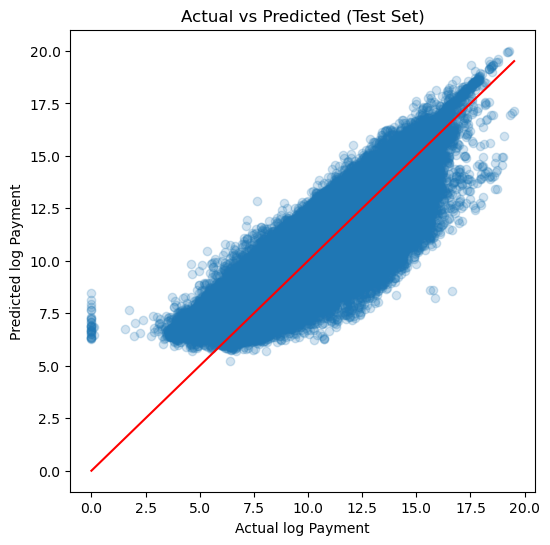

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.2)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.xlabel("Actual log Payment")
plt.ylabel("Predicted log Payment")
plt.title("Actual vs Predicted (Test Set)")
plt.show()

# Residuals

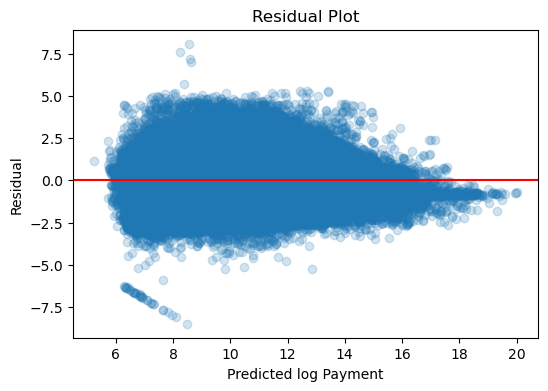

In [11]:
residuals = y_test - pred

plt.figure(figsize=(6,4))
plt.scatter(pred, residuals, alpha=0.2)
plt.axhline(0, color="red")
plt.xlabel("Predicted log Payment")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

# Provider Type Effect (median payments)

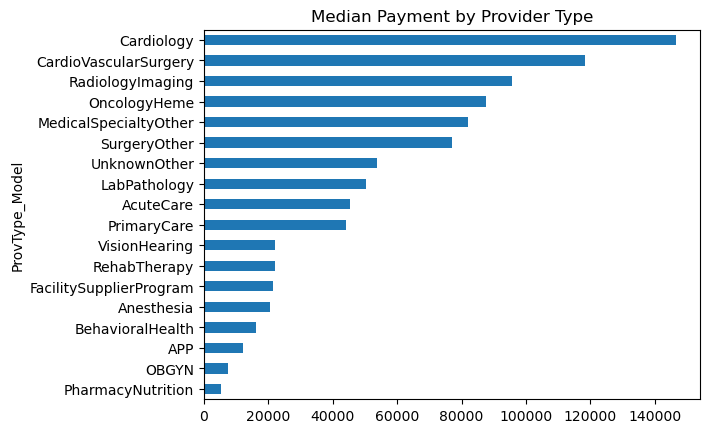

In [12]:
df.groupby("ProvType_Model")["Tot_Mdcr_Pymt_Amt"].median().sort_values().plot(kind="barh")
plt.title("Median Payment by Provider Type")
plt.show()

# Coefficients

In [13]:
import pandas as pd

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
}).sort_values(by="coefficient", key=abs, ascending=False)

coef_df.head(15)

,feature,coefficient
8,cat__ProvType_Model_CardioVascularSurgery,1.356627
3,num__Drug_Service_Share,-0.963438
19,cat__ProvType_Model_SurgeryOther,0.808669
6,cat__ProvType_Model_Anesthesia,0.781996
1,num__log_Tot_Srvcs,0.749682
14,cat__ProvType_Model_OncologyHeme,0.680206
7,cat__ProvType_Model_BehavioralHealth,0.565136
17,cat__ProvType_Model_RadiologyImaging,-0.507128
11,cat__ProvType_Model_LabPathology,-0.440649
5,cat__ProvType_Model_AcuteCare,0.433042


From here we can see CardioVascularSurgery providers have payments almost 4x higher than the baseline provider type(APP) after controlling for volume and risk (makes sense clinically), higher drug share is associated with lower total medicare payment, after controling for volume(drug heavy providers may have fewer serives or drug billing scales differently than procedure billing), Also, log_Tot_Srvcs is ~.75 so a 1% increase in services leads to .75% increase in payment. A 1% increase in beneficiaries leads to a .3% increase in payments (so services matter more than raw beneficiary count)

We can conclude service volume has strong elasticity, while beneficiary count contributes more modestly (.75 vs .3). However, specialty type produces substantial structural shifts in payment levels. Ex. CardioVascularSurgery
